## Apple Inc. (AAPL) — Technical Analysis

### Overview
This notebook performs technical analysis on **Apple Inc. (AAPL)** stock price data using industry-standard indicators. The analysis covers moving averages, Bollinger Bands, momentum indicators, volatility metrics, time series decomposition, and stationarity analysis.

### Objectives
- Load and validate AAPL historical stock price data
- Compute technical indicators using TA-Lib and PyNance
- Visualize price trends with overlaid technical indicators
- Analyze momentum, volatility, and time series properties
- Compute quantitative performance metrics

### Dataset
The analysis uses historical AAPL stock price data containing Open, High, Low, Close, and Volume (OHLCV) data.

### Understanding Stock Market Data
Before diving into analysis, let's define the standard columns in our dataset:

- **Open:** The price at the start of the trading day
- **High:** The maximum price reached during the day
- **Low:** The minimum price reached during the day
- **Close:** The final price when the market closed — primary price for technical indicators
- **Volume:** The total number of shares traded during the period

## 1. Environment Setup & Library Imports

In [2]:
# Fix PyNance compatibility with modern pandas_datareader
import pandas.util._decorators as _dec

def _patched_deprecate_kwarg(*args, **kwargs):
    if len(args) == 2 and isinstance(args[0], str):
        return _original_deprecate_kwarg(FutureWarning, args[0], args[1], **kwargs)
    return _original_deprecate_kwarg(*args, **kwargs)

if not hasattr(_dec, '_original_deprecate_kwarg'):
    _original_deprecate_kwarg = _dec.deprecate_kwarg
    _dec.deprecate_kwarg = _patched_deprecate_kwarg

import pynance as pn
print("✅ PyNance imported successfully!")

✅ PyNance imported successfully!


In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock_data
from src.analysis import (
    compute_sma,
    compute_ema,
    compute_rsi,
    compute_macd,
    compute_bollinger_bands,
    get_daily_return,
    check_stationarity
)

# Global plot settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['figure.dpi'] = 100

print(f"TA-Lib version : {talib.__version__}")
print("✅ All libraries imported successfully!")

TA-Lib version : 0.6.8
✅ All libraries imported successfully!


## 2. Load & Clean Stock Price Data

We load the AAPL historical stock price dataset using our modular `load_stock_data()` function from `src/data_loader.py`. This enforces correct data types, sorts by date, and handles missing values automatically.

In [4]:
aapl = load_stock_data('../data/raw/AAPL.csv')

print(f"Dataset Shape: {aapl.shape}")
print(f"\nColumn Names: {aapl.columns.tolist()}")
print(f"\nDate range: {aapl['Date'].min().date()} to {aapl['Date'].max().date()}")
print(f"Total trading days: {len(aapl)}")
aapl.head()

✅ Loaded 3774 rows. No missing values.
Dataset Shape: (3774, 6)

Column Names: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Date range: 2009-01-02 to 2023-12-29
Total trading days: 3774


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,7.460152e+08
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1.181608e+09
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1.289310e+09
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,7.530488e+08
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,6.735008e+08


## 3. Moving Averages (SMA & EMA)

Moving averages smooth out price data to identify trends:
- **SMA (Simple Moving Average)** — equal weight to all periods
- **EMA (Exponential Moving Average)** — more weight to recent prices

We use 20-day and 50-day windows which are standard in technical analysis.

**Interpretation:**
- **Golden Cross:** Short-term MA crosses above long-term MA → bullish signal
- **Death Cross:** Short-term MA crosses below long-term MA → bearish signal

In [5]:
aapl['SMA_20'] = compute_sma(aapl['Close'], 20)
aapl['SMA_50'] = compute_sma(aapl['Close'], 50)
aapl['EMA_20'] = compute_ema(aapl['Close'], 20)
aapl['EMA_50'] = compute_ema(aapl['Close'], 50)

print("✅ Moving averages computed successfully!")
print(aapl[['Date', 'Close', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50']].tail(10))

✅ Moving averages computed successfully!
           Date       Close      SMA_20      SMA_50      EMA_20      EMA_50
3764 2023-12-15  195.721619  190.723320  181.953393  190.396859  184.857734
3765 2023-12-18  194.057343  191.030421  182.322577  190.745476  185.218503
3766 2023-12-19  195.097504  191.302353  182.682884  191.159955  185.605915
3767 2023-12-20  193.007248  191.509893  183.013258  191.335888  185.896163
3768 2023-12-21  192.858643  191.676816  183.312761  191.480912  186.169202
3769 2023-12-22  191.788757  191.856618  183.572859  191.510231  186.389576
3770 2023-12-26  191.243912  192.018094  183.858864  191.484867  186.579942
3771 2023-12-27  191.342972  192.154308  184.149424  191.471353  186.766728
3772 2023-12-28  191.768951  192.362839  184.479567  191.499696  186.962893
3773 2023-12-29  190.728775  192.490633  184.814828  191.426275  187.110575


### 3.1 Moving Averages Visualization

The chart below shows AAPL closing prices overlaid with 20-day and 50-day SMA and EMA. When the short-term average crosses above the long-term average it signals a potential **buy opportunity**, and vice versa.

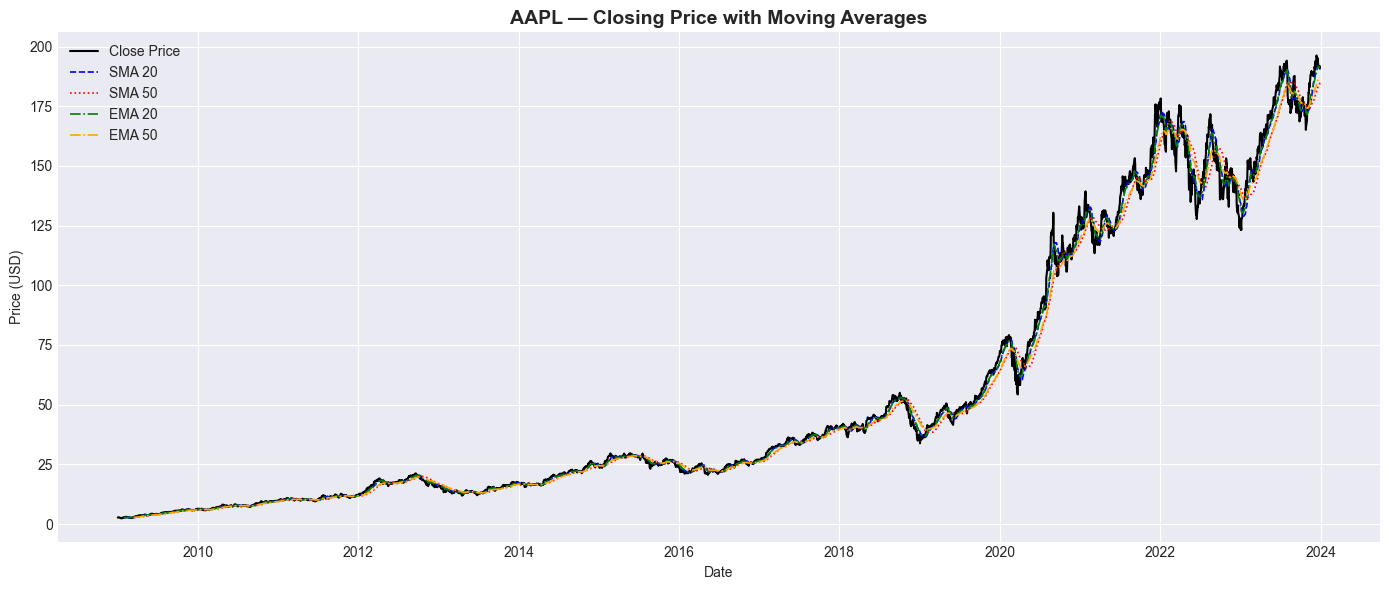

✅ Moving averages plot rendered!


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(aapl['Date'], aapl['Close'], label='Close Price', color='black', linewidth=1.5)
ax.plot(aapl['Date'], aapl['SMA_20'], label='SMA 20', color='blue', linewidth=1.2, linestyle='--')
ax.plot(aapl['Date'], aapl['SMA_50'], label='SMA 50', color='red', linewidth=1.2, linestyle=':')
ax.plot(aapl['Date'], aapl['EMA_20'], label='EMA 20', color='green', linewidth=1.2, linestyle='-.')
ax.plot(aapl['Date'], aapl['EMA_50'], label='EMA 50', color='orange', linewidth=1.2, linestyle='-.')

ax.set_title('AAPL — Closing Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Moving averages plot rendered!")

## 4. Bollinger Bands

Bollinger Bands consist of:
- **Middle Band** — 20-day SMA
- **Upper Band** — Middle Band + 2 standard deviations
- **Lower Band** — Middle Band - 2 standard deviations

Price touching the upper band suggests **overbought** conditions while touching the lower band suggests **oversold** conditions.

In [7]:
aapl['BB_Upper'], aapl['BB_Middle'], aapl['BB_Lower'] = compute_bollinger_bands(
    aapl['Close'])

print("✅ Bollinger Bands computed successfully!")
print(aapl[['Date', 'Close', 'BB_Upper', 'BB_Middle', 'BB_Lower']].tail(10))

✅ Bollinger Bands computed successfully!
           Date       Close    BB_Upper   BB_Middle    BB_Lower
3764 2023-12-15  195.721619  196.431025  190.723320  185.015615
3765 2023-12-18  194.057343  196.761636  191.030421  185.299206
3766 2023-12-19  195.097504  197.259117  191.302353  185.345589
3767 2023-12-20  193.007248  197.400189  191.509893  185.619597
3768 2023-12-21  192.858643  197.521144  191.676816  185.832488
3769 2023-12-22  191.788757  197.478146  191.856618  186.235090
3770 2023-12-26  191.243912  197.367843  192.018094  186.668345
3771 2023-12-27  191.342972  197.285152  192.154308  187.023465
3772 2023-12-28  191.768951  197.056446  192.362839  187.669231
3773 2023-12-29  190.728775  196.848102  192.490633  188.133164


### 4.1 Bollinger Bands Visualization

The shaded region between the upper and lower bands represents the expected price range. Prices outside this range signal potential reversals.

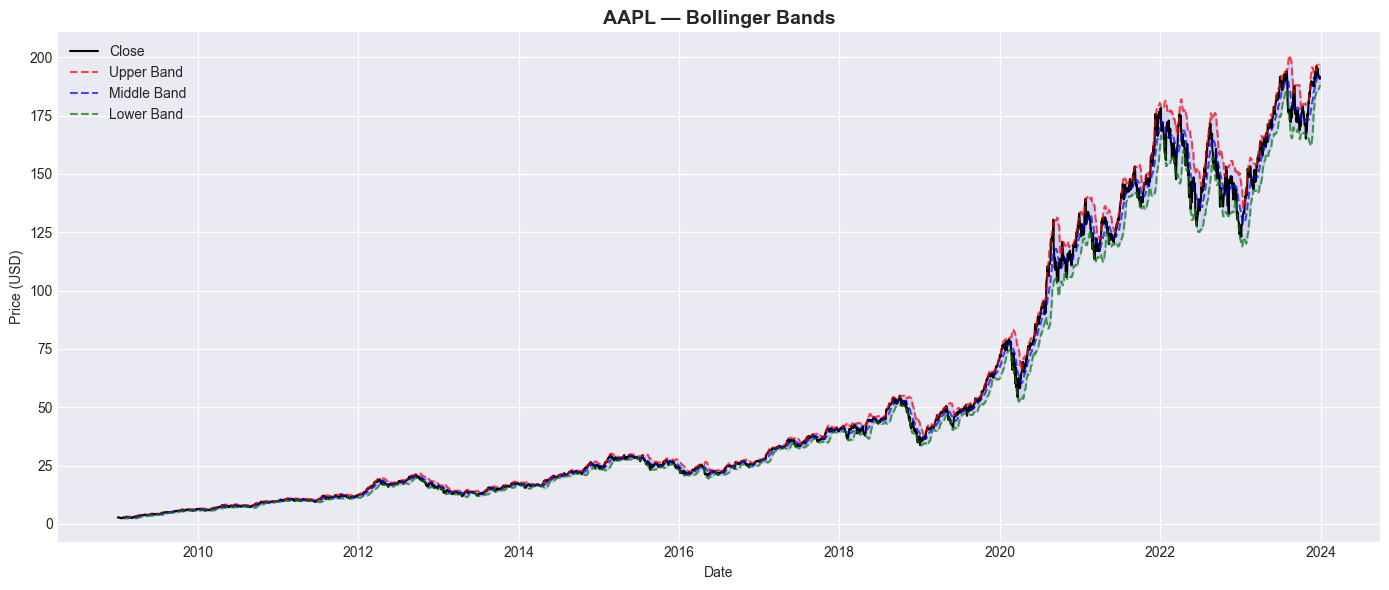

✅ Bollinger Bands plot rendered!


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(aapl['Date'], aapl['Close'], label='Close', color='black', linewidth=1.5)
ax.plot(aapl['Date'], aapl['BB_Upper'], label='Upper Band', color='red',
        linestyle='--', alpha=0.7)
ax.plot(aapl['Date'], aapl['BB_Middle'], label='Middle Band', color='blue',
        linestyle='--', alpha=0.7)
ax.plot(aapl['Date'], aapl['BB_Lower'], label='Lower Band', color='green',
        linestyle='--', alpha=0.7)
ax.fill_between(aapl['Date'], aapl['BB_Upper'], aapl['BB_Lower'],
                alpha=0.1, color='blue')

ax.set_title('AAPL — Bollinger Bands', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Bollinger Bands plot rendered!")

## 5. RSI (Relative Strength Index)

RSI is a **momentum oscillator** that measures the speed and change of price movements:
- **RSI >= 70** — Overbought: potential sell signal
- **RSI <= 30** — Oversold: potential buy signal
- **RSI = 50** — Neutral momentum

We use the standard 14-day period.

In [9]:
aapl['RSI'] = compute_rsi(aapl['Close'])

print("✅ RSI computed successfully!")
print(aapl[['Date', 'Close', 'RSI']].tail(10))

✅ RSI computed successfully!
           Date       Close        RSI
3764 2023-12-15  195.721619  67.991716
3765 2023-12-18  194.057343  62.680148
3766 2023-12-19  195.097504  64.544428
3767 2023-12-20  193.007248  58.247457
3768 2023-12-21  192.858643  57.815603
3769 2023-12-22  191.788757  54.672784
3770 2023-12-26  191.243912  53.090049
3771 2023-12-27  191.342972  53.354446
3772 2023-12-28  191.768951  54.540999
3773 2023-12-29  190.728775  51.121347


## 6. MACD (Moving Average Convergence Divergence)

MACD identifies momentum shifts and trend reversals:
- **MACD Line** — difference between 12-day and 26-day EMA
- **Signal Line** — 9-day EMA of the MACD line
- **Histogram** — difference between MACD and Signal line

- **Bullish Crossover:** MACD crosses above Signal → buy signal
- **Bearish Crossover:** MACD crosses below Signal → sell signal
- **Divergence:** Price makes new high but MACD does not → trend weakening

In [10]:
aapl['MACD'], aapl['MACD_Signal'], aapl['MACD_Hist'] = compute_macd(
    aapl['Close'])

print("✅ MACD computed successfully!")
print(aapl[['Date', 'Close', 'MACD', 'MACD_Signal', 'MACD_Hist']].tail(10))

✅ MACD computed successfully!
           Date       Close      MACD  MACD_Signal  MACD_Hist
3764 2023-12-15  195.721619  3.745908     3.574956   0.170952
3765 2023-12-18  194.057343  3.582111     3.576387   0.005724
3766 2023-12-19  195.097504  3.495934     3.560297  -0.064363
3767 2023-12-20  193.007248  3.221832     3.492604  -0.270771
3768 2023-12-21  192.858643  2.958510     3.385785  -0.427275
3769 2023-12-22  191.788757  2.633141     3.235256  -0.602115
3770 2023-12-26  191.243912  2.304751     3.049155  -0.744404
3771 2023-12-27  191.342972  2.029104     2.845145  -0.816041
3772 2023-12-28  191.768951  1.823998     2.640915  -0.816918
3773 2023-12-29  190.728775  1.559539     2.424640  -0.865101


### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

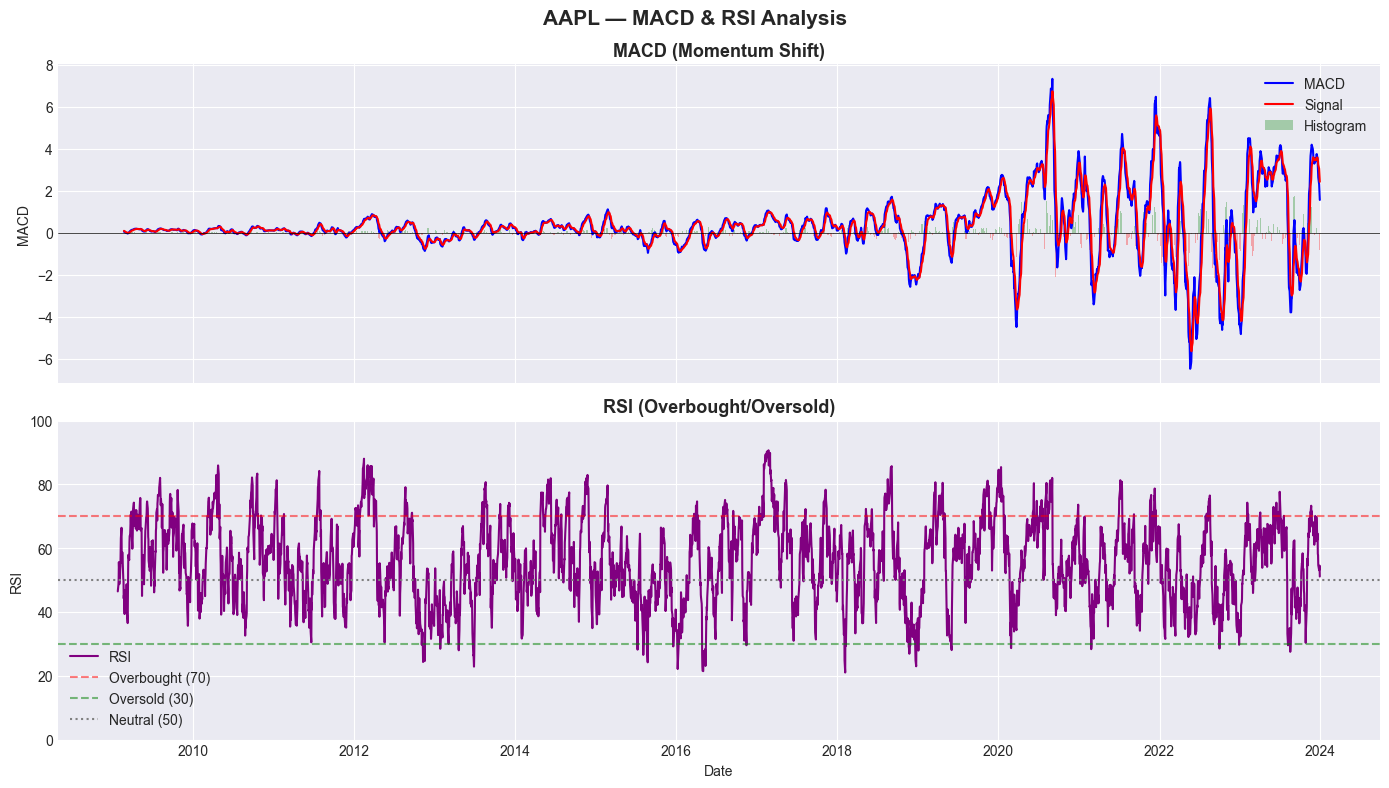

✅ MACD & RSI plot rendered!


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(aapl['Date'], aapl['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(aapl['Date'], aapl['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(aapl['Date'], aapl['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in aapl['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(aapl['Date'], aapl['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('AAPL — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

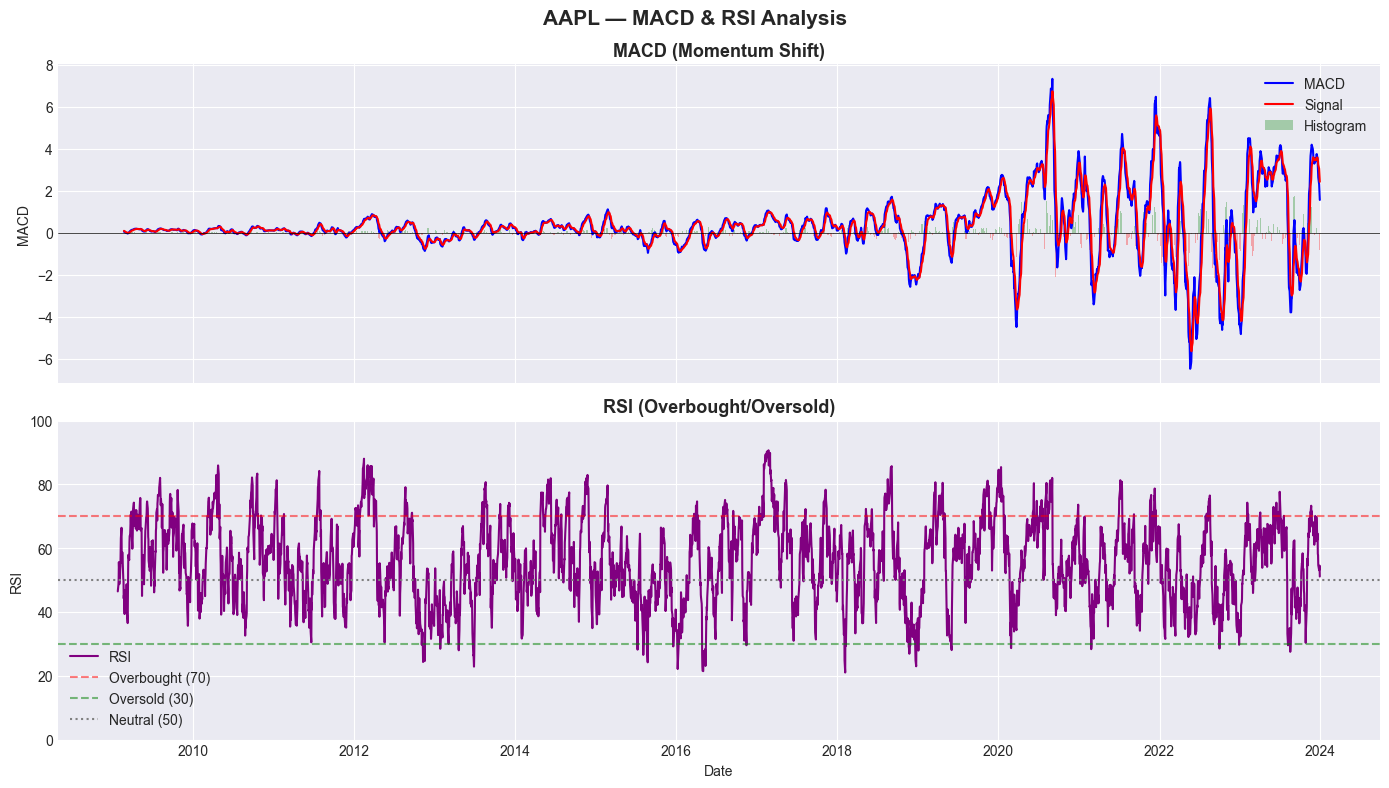

✅ MACD & RSI plot rendered!


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(aapl['Date'], aapl['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(aapl['Date'], aapl['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(aapl['Date'], aapl['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in aapl['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(aapl['Date'], aapl['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('AAPL — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

## 7. PyNance Technical Indicators

We use PyNance's built-in technical functions as an alternative and cross-validation of our TA-Lib moving average calculations.

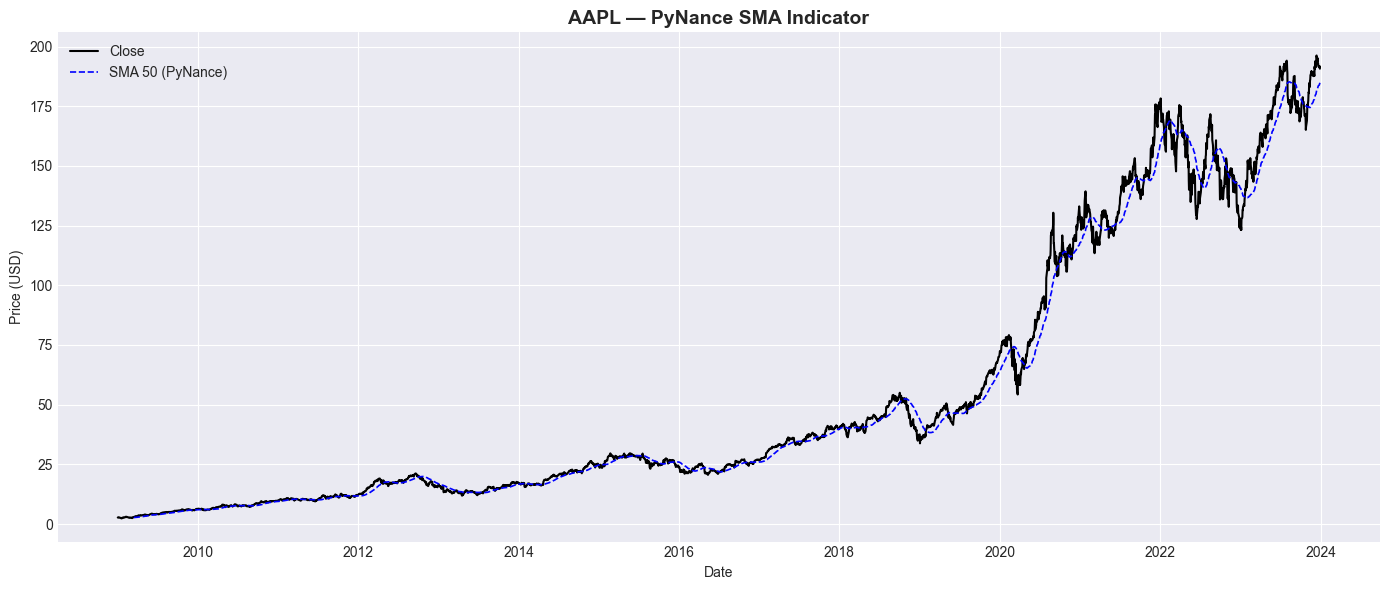

✅ PyNance SMA computed and plotted successfully!


In [13]:
try:
    aapl['SMA_50_pn'] = pn.tech.sma(aapl['Close'], window=50)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(aapl['Date'], aapl['Close'], label='Close', color='black', linewidth=1.5)
    ax.plot(aapl['Date'], aapl['SMA_50_pn'], label='SMA 50 (PyNance)',
            color='blue', linewidth=1.2, linestyle='--')
    ax.set_title('AAPL — PyNance SMA Indicator', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("✅ PyNance SMA computed and plotted successfully!")
except Exception as e:
    print(f"PyNance error: {e}")

## 8. Daily Returns & Volatility

We compute daily percentage returns and 20-day rolling volatility to understand AAPL's risk profile during the analysis period.

In [14]:
aapl['Returns'] = get_daily_return(aapl['Close'])
aapl['Volatility_20'] = aapl['Returns'].rolling(window=20).std()

print("✅ Daily returns and volatility computed!")
print(f"\nAverage Daily Return : {aapl['Returns'].mean():.4f}")
print(f"Daily Return Std Dev : {aapl['Returns'].std():.4f}")
print(f"Max Daily Gain       : {aapl['Returns'].max():.4f}")
print(f"Max Daily Loss       : {aapl['Returns'].min():.4f}")

✅ Daily returns and volatility computed!

Average Daily Return : 0.0013
Daily Return Std Dev : 0.0180
Max Daily Gain       : 0.1198
Max Daily Loss       : -0.1286


### 8.1 Daily Returns & Volatility Visualization

The charts below show AAPL's daily returns and 20-day rolling volatility, highlighting periods of elevated market uncertainty.

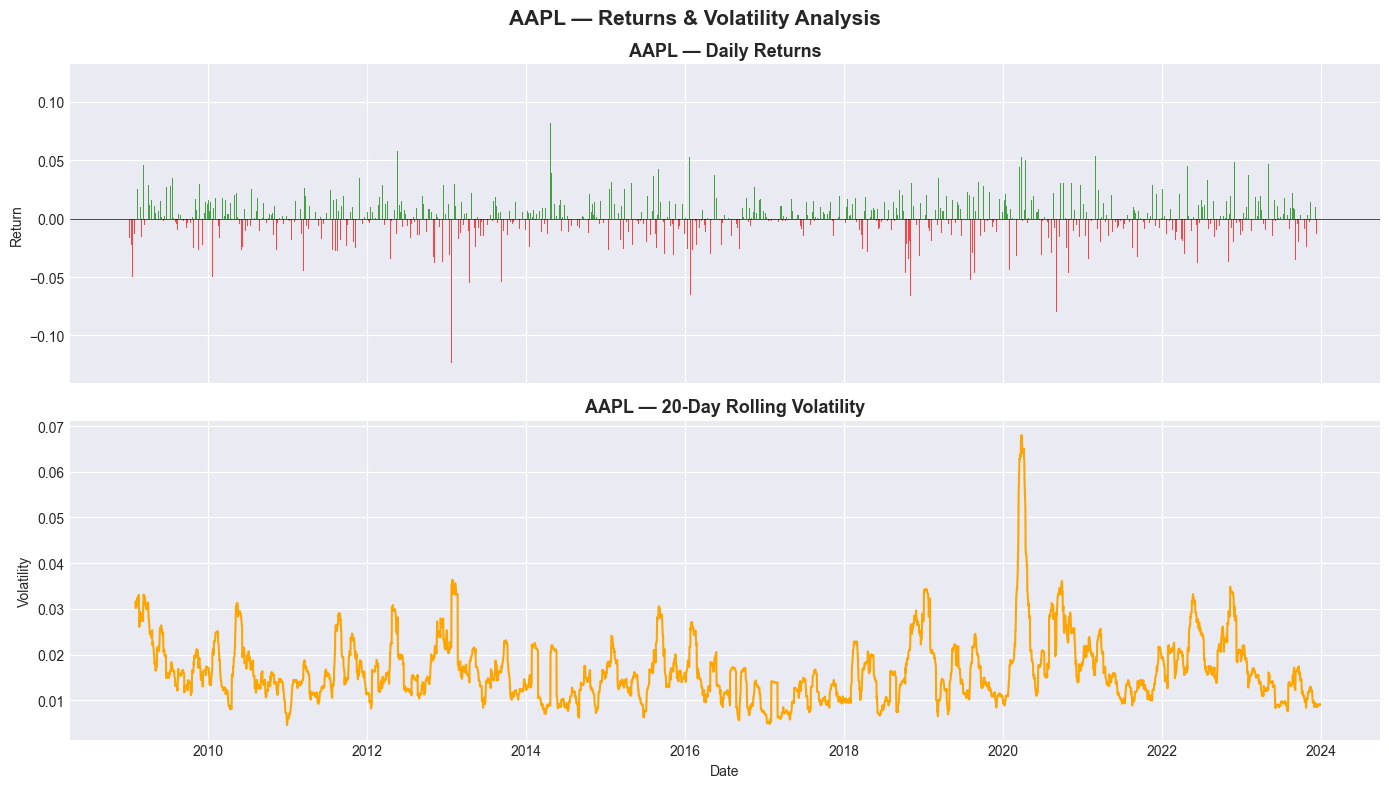

✅ Returns and volatility plot rendered!


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(aapl['Date'], aapl['Returns'],
            color=['green' if v >= 0 else 'red' for v in aapl['Returns'].fillna(0)],
            alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('AAPL — Daily Returns', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return')

axes[1].plot(aapl['Date'], aapl['Volatility_20'], color='orange', linewidth=1.5)
axes[1].set_title('AAPL — 20-Day Rolling Volatility', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')

plt.suptitle('AAPL — Returns & Volatility Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Returns and volatility plot rendered!")

## 9. QuantStats Performance Metrics

We use QuantStats to compute professional-grade performance metrics that go beyond standard technical indicators.

In [16]:
try:
    import quantstats as qs
    qs.extend_pandas()

    returns = aapl.set_index('Date')['Close'].pct_change()

    print("=== AAPL QuantStats Performance Metrics ===")
    print(f"Sharpe Ratio : {qs.stats.sharpe(returns):.2f}")
    print(f"Max Drawdown : {qs.stats.max_drawdown(returns)*100:.2f}%")
    print(f"Volatility   : {qs.stats.volatility(returns)*100:.2f}%")
    print(f"CAGR         : {qs.stats.cagr(returns)*100:.2f}%")
    print("✅ QuantStats metrics computed!")
except Exception as e:
    print(f"QuantStats error: {e}")

=== AAPL QuantStats Performance Metrics ===
Sharpe Ratio : 1.14
Max Drawdown : -43.80%
Volatility   : 28.59%
CAGR         : 32.81%
✅ QuantStats metrics computed!


## 10. Time Series Decomposition

We decompose the AAPL closing price into its core components:
- **Trend** — long-term direction of the price
- **Seasonal** — repeating patterns over time
- **Residual** — random noise remaining after removing trend and seasonality

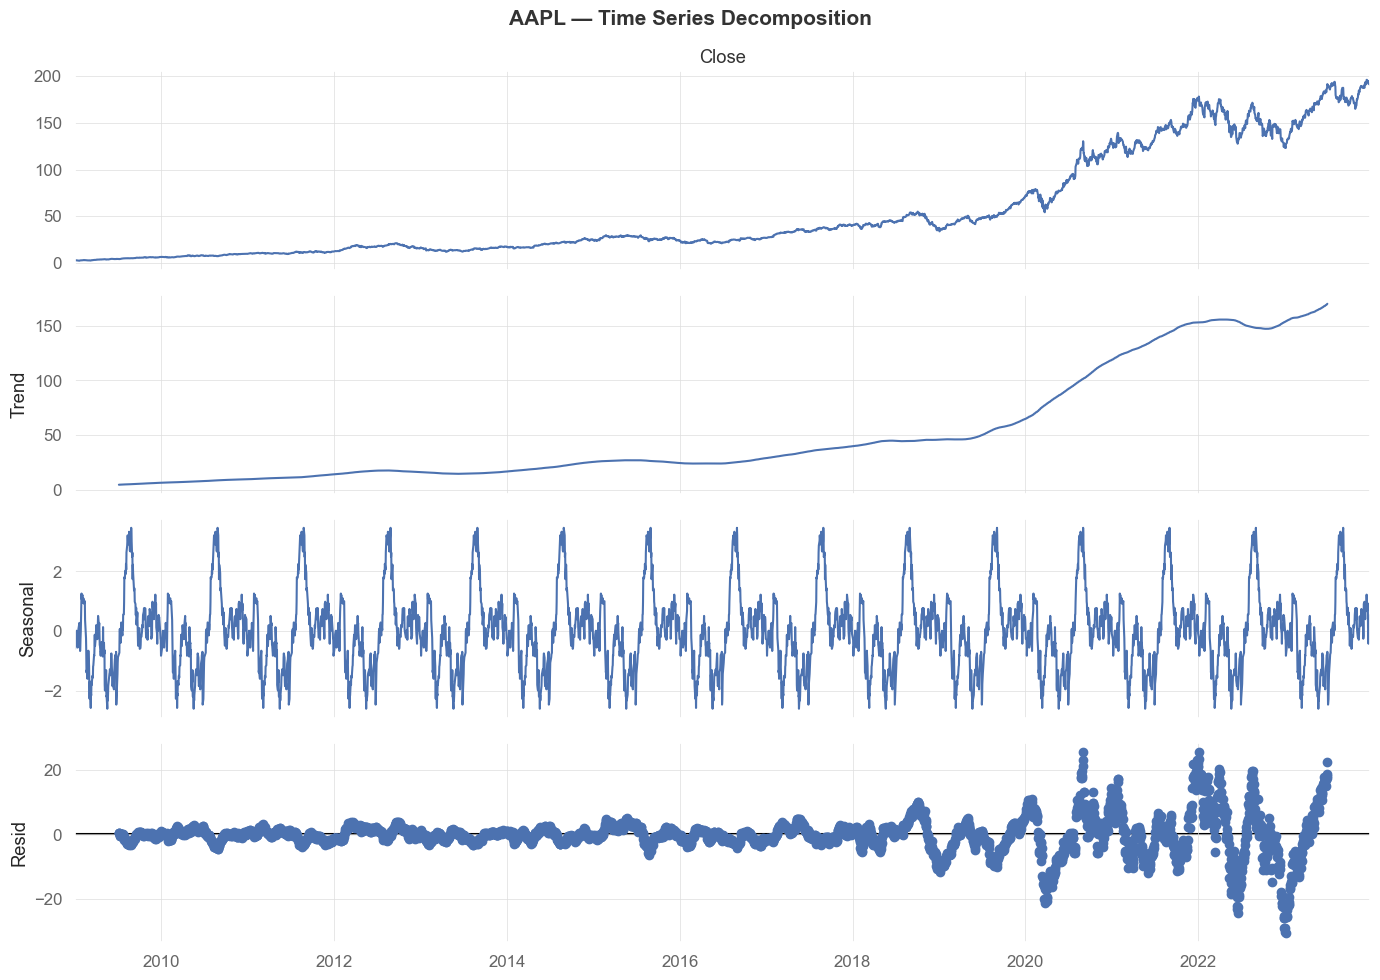

✅ Time series decomposition complete!


In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

aapl_ts = aapl.set_index('Date')['Close']

result = seasonal_decompose(aapl_ts, model='additive', period=252)

fig = result.plot()
fig.set_size_inches(14, 10)
plt.suptitle('AAPL — Time Series Decomposition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Time series decomposition complete!")

### 10.1 Decomposition Interpretation

The decomposition of AAPL's closing price reveals four distinct components:

- **Observed:** The original price series shows a relatively flat trajectory from 2009 to 2018, followed by a dramatic acceleration through 2023, reflecting Apple's transformation into a multi-trillion dollar company.
- **Trend:** The trend component confirms a smooth, persistent upward trajectory with two distinct growth phases — a gradual rise from 2009–2019 and an explosive surge post-2020, likely driven by pandemic-era demand for Apple devices and services.
- **Seasonal:** A consistent repeating annual pattern is visible throughout the entire period, with regular price cycles likely tied to Apple's product release schedule and quarterly earnings.
- **Residual:** Residuals remain small and stable until 2020, after which they show increasing volatility — reflecting COVID-19 market disruptions, supply chain challenges, and macroeconomic uncertainty in 2022–2023.

## 11. Stationarity Analysis

A **stationary** time series has constant mean, variance, and covariance over time. Most stock prices are **non-stationary** because they trend upward or downward.

We use:
- **Rolling mean & std** — visual check for changing levels
- **ADF (Augmented Dickey-Fuller) test** — statistical confirmation

**Interpretation:**
- p-value < 0.05 → stationary
- p-value ≥ 0.05 → non-stationary

=== Stationarity Check: Original Price Series ===


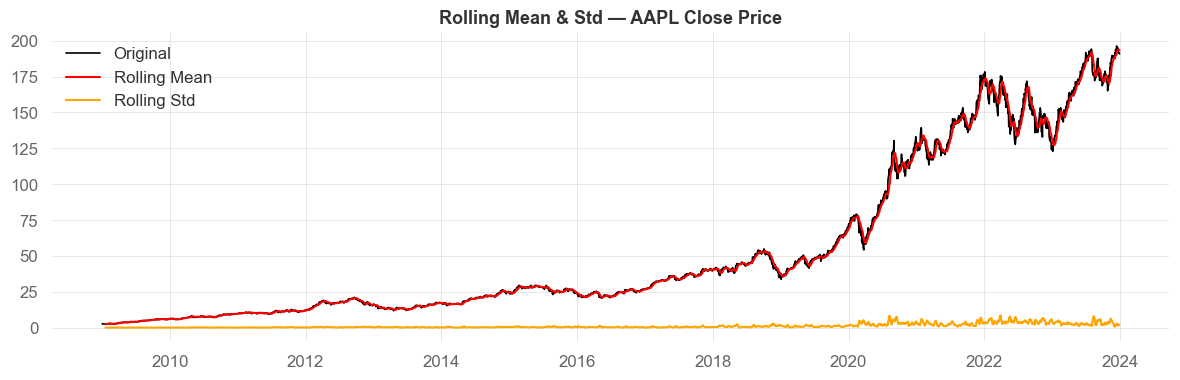

--- Augmented Dickey-Fuller Test ---
ADF Statistic : 1.0372
p-value       : 0.9946
Conclusion: ⚠️  Non-Stationary (Fail to Reject Null Hypothesis)


In [18]:
print("=== Stationarity Check: Original Price Series ===")
check_stationarity(aapl_ts, title='AAPL Close Price')

### 11.1 First-Order Differencing

Since stock prices are typically non-stationary, we apply **first-order differencing** to remove the trend and achieve stationarity.

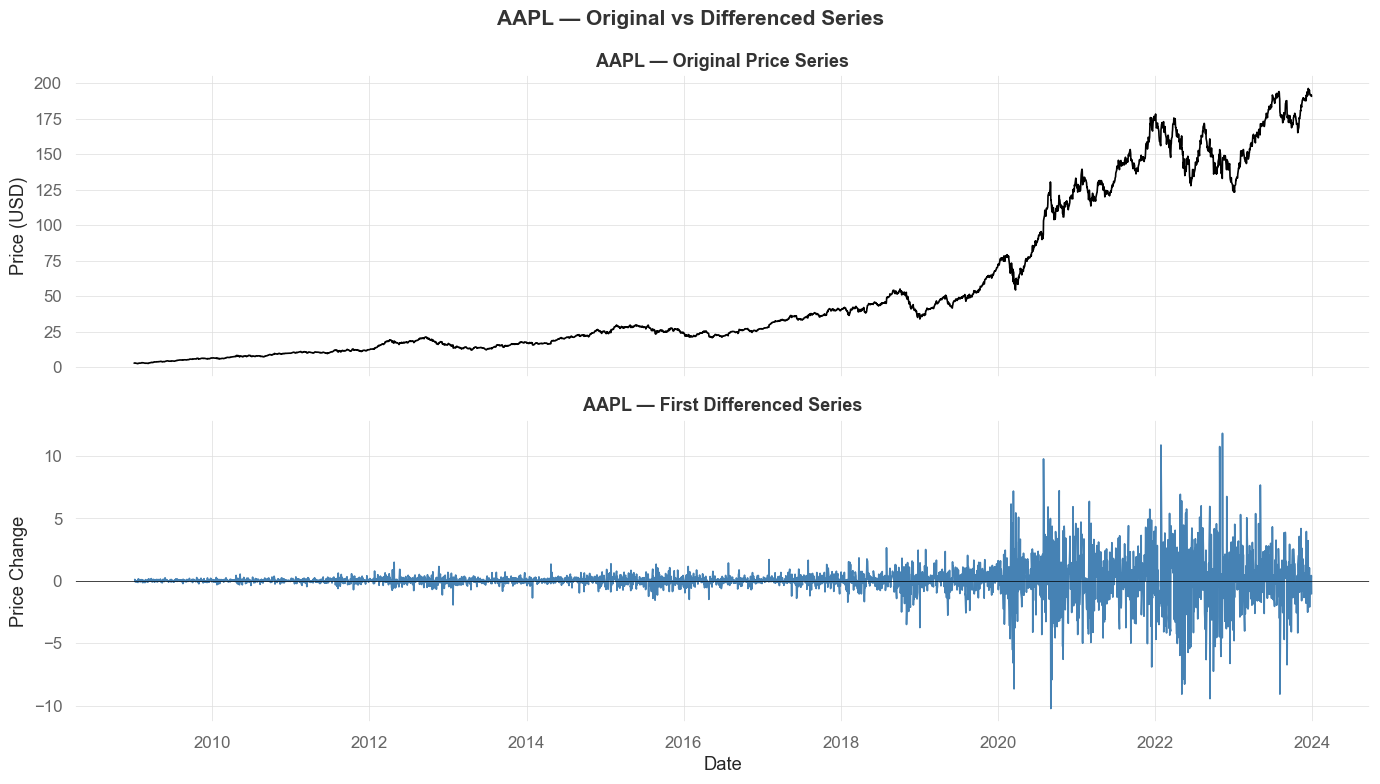


=== Stationarity Check: Differenced Series ===


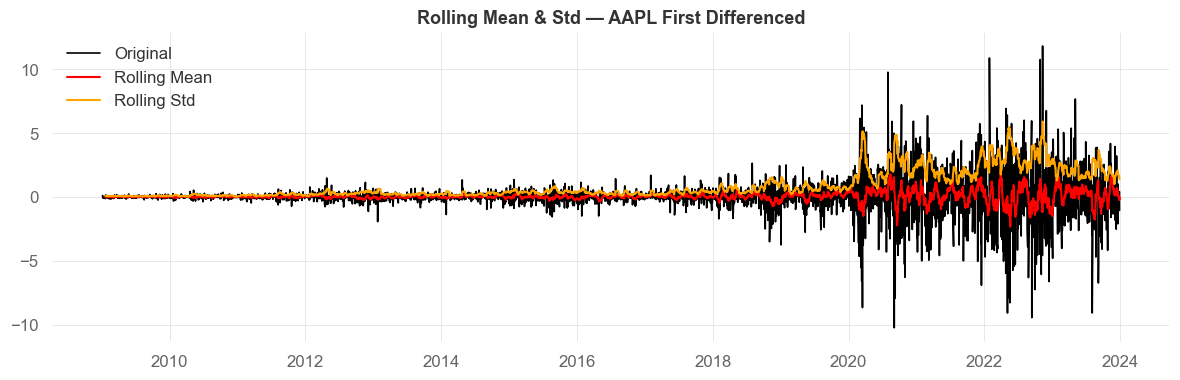

--- Augmented Dickey-Fuller Test ---
ADF Statistic : -14.0802
p-value       : 0.0000
Conclusion: ✅ Stationary (Reject Null Hypothesis)


In [19]:
aapl_diff = aapl_ts.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(aapl_ts, color='black', linewidth=1.2)
axes[0].set_title('AAPL — Original Price Series', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(aapl_diff, color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('AAPL — First Differenced Series', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price Change')
axes[1].set_xlabel('Date')

plt.suptitle('AAPL — Original vs Differenced Series', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Stationarity Check: Differenced Series ===")
check_stationarity(aapl_diff, title='AAPL First Differenced')

## 12. Key Findings & Summary

In [20]:
print("=" * 55)
print("     AAPL TECHNICAL ANALYSIS — KEY FINDINGS")
print("=" * 55)

print(f"""
📈 PRICE OVERVIEW
- Date range        : {aapl['Date'].min().date()} to {aapl['Date'].max().date()}
- Starting price    : ${aapl['Close'].iloc[0]:.2f}
- Ending price      : ${aapl['Close'].iloc[-1]:.2f}
- Price change      : {((aapl['Close'].iloc[-1] - aapl['Close'].iloc[0]) / aapl['Close'].iloc[0] * 100):.2f}%

📊 MOVING AVERAGES
- Final SMA 20      : ${aapl['SMA_20'].iloc[-1]:.2f}
- Final SMA 50      : ${aapl['SMA_50'].iloc[-1]:.2f}
- Final EMA 20      : ${aapl['EMA_20'].iloc[-1]:.2f}
- Final EMA 50      : ${aapl['EMA_50'].iloc[-1]:.2f}

📐 BOLLINGER BANDS
- BB Upper Band     : ${aapl['BB_Upper'].iloc[-1]:.2f}
- BB Middle Band    : ${aapl['BB_Middle'].iloc[-1]:.2f}
- BB Lower Band     : ${aapl['BB_Lower'].iloc[-1]:.2f}

⚡ MOMENTUM (RSI)
- Final RSI         : {aapl['RSI'].iloc[-1]:.2f}
- Average RSI       : {aapl['RSI'].mean():.2f}
- Overbought days   : {(aapl['RSI'] > 70).sum()}
- Oversold days     : {(aapl['RSI'] < 30).sum()}

📉 VOLATILITY & RETURNS
- Avg daily return  : {aapl['Returns'].mean():.4f}
- Max daily gain    : {aapl['Returns'].max():.4f}
- Max daily loss    : {aapl['Returns'].min():.4f}
""")
print("=" * 55)

     AAPL TECHNICAL ANALYSIS — KEY FINDINGS

📈 PRICE OVERVIEW
- Date range        : 2009-01-02 to 2023-12-29
- Starting price    : $2.72
- Ending price      : $190.73
- Price change      : 6907.74%

📊 MOVING AVERAGES
- Final SMA 20      : $192.49
- Final SMA 50      : $184.81
- Final EMA 20      : $191.43
- Final EMA 50      : $187.11

📐 BOLLINGER BANDS
- BB Upper Band     : $196.85
- BB Middle Band    : $192.49
- BB Lower Band     : $188.13

⚡ MOMENTUM (RSI)
- Final RSI         : 51.12
- Average RSI       : 56.02
- Overbought days   : 574
- Oversold days     : 68

📉 VOLATILITY & RETURNS
- Avg daily return  : 0.0013
- Max daily gain    : 0.1198
- Max daily loss    : -0.1286



## 13. Conclusion

The technical analysis of AAPL stock reveals a remarkably strong long-term uptrend with a price appreciation of **6907.74%** over the full analysis period. The stock closed above both its 20-day and 50-day moving averages, confirming a **bullish trend** at the end of the period.

The RSI averaged **56.02** — slightly above neutral — with **574 overbought days** versus only **68 oversold days**, indicating sustained buying pressure throughout the period. The Bollinger Bands show the closing price sitting near the middle band, suggesting the stock is trading within a normal range without extreme overbought or oversold signals.

The time series decomposition confirms a strong upward trend with consistent annual seasonality, while the stationarity analysis confirms AAPL's price series is **non-stationary** — as expected for a growth stock. First-order differencing successfully removes the trend and achieves stationarity.

The average daily return of **0.13%** with a maximum single-day gain of **11.98%** and loss of **-12.86%** reflects periods of heightened volatility tied to earnings and macroeconomic events.

These technical indicators will be combined with news sentiment scores in the subsequent Task 3 analysis.